<div style="background: linear-gradient(135deg, #1a3a5c 0%, #2e6da4 100%); padding: 32px 28px; border-radius: 12px; color: white; margin-bottom: 8px;">
  <h1 style="margin:0; font-size:2em; font-weight:800;">Programming Assignment 2</h1>
  <h2 style="margin:6px 0 0 0; font-weight:400; opacity:0.9;">PyTorch CNN — FashionMNIST Classifier</h2>
  <p style="margin:10px 0 0 0; opacity:0.75; font-size:0.95em;">DSE 220 MAS &nbsp;|&nbsp; Deep Learning with PyTorch · Convolutional Neural Networks</p>
</div>

> **Questionnaire notebook.** Fill in every `# TODO` block. Do not modify any other code unless instructed.

**Starters on PyTorch**
> Before implementing this assignment, please make sure you are comfortable with the basic PyTorch workflow.

> 1. Review Chapters 00 and 01 from the [PyTorch book](https://www.learnpytorch.io/)
These chapters introduce the core concepts needed for building, training, and evaluating models in PyTorch.
2. If you prefer learning through videos, you may instead watch the following introductory tutorial: [Youtube Video](https://youtu.be/r1bquDz5GGA?si=doDWs2mlSLElT4hq)

## 📋 Table of Contents
1. [Setup & Device Check](#setup)
2. [Dataset Overview](#overview)
3. [Data Visualization](#viz)
4. [DataLoaders](#dataloader)
5. [Baseline Linear Model — Rubric A](#baseline)
6. [Training & Evaluation Loops](#loops)
7. [Run Baseline Experiments — Rubric B](#run_baseline)
8. [Build a CNN — Rubric C](#cnn)
9. [Train & Compare CNN vs Baseline — Rubric D](#compare)
10. [Plots & Analysis — Rubric E](#plots)
11. [Save the Model](#save)
12. [Team Contributions](#team)
13. [AI Use Log](#ailog)


---
## 1. Setup & Device Check <a id='setup'></a>

Run this cell first. It installs dependencies, imports all required libraries, sets random seeds for reproducibility, and **prints which device your runtime is using** (CPU or CUDA GPU).

> 💡 **If you are on Google Colab:** go to `Runtime → Change runtime type → GPU` before running. You will see `Using device: cuda` if a GPU is assigned.


In [1]:
# ── Install / verify dependencies ──────────────────────────────────────────
# (torch and torchvision are pre-installed on Colab; run locally if needed)
# !pip install torch torchvision matplotlib --quiet

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.data import random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import os, copy, time

# ── Reproducibility seeds ──────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ── Device-agnostic setup ──────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"  GPU name : {torch.cuda.get_device_name(0)}")
    print(f"  CUDA ver : {torch.version.cuda}")
else:
    print("  Running on CPU — training will be slower. Enable GPU in Colab for faster results.")

print("All imports successful.")


Using device: cuda
  GPU name : Tesla T4
  CUDA ver : 12.8
All imports successful.


---
## 2. Dataset Overview <a id='overview'></a>

**FashionMNIST** is a drop-in replacement for MNIST, consisting of 70,000 grayscale images (28×28 px) of clothing across 10 classes.

| Split | Samples |
|:---:|:---:|
| Train | 60,000 |
| Test | 10,000 |

| Label | Class |
|:---:|:---:|
| 0 | T-Shirt/Top |
| 1 | Trouser |
| 2 | Pullover |
| 3 | Dress |
| 4 | Coat |
| 5 | Sandal |
| 6 | Shirt |
| 7 | Sneaker |
| 8 | Bag |
| 9 | Ankle Boot |

Each pixel value lies in [0, 255]. We will normalise using the **dataset-level mean (0.2860) and std (0.3530)** so that all inputs are roughly N(0,1).


In [2]:
# FashionMNIST class labels
CLASSES = ["T-Shirt", "Trouser", "Pullover", "Dress", "Coat",
           "Sandal",  "Shirt",   "Sneaker",  "Bag",   "Ankle Boot"]
NUM_CLASSES = len(CLASSES)

# Dataset-level normalisation statistics (pre-computed on train split)
FASHION_MEAN = (0.2860,)
FASHION_STD  = (0.3530,)

print(f"Number of classes : {NUM_CLASSES}")
print(f"Classes           : {CLASSES}")


Number of classes : 10
Classes           : ['T-Shirt', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot']


---
## 3. Data Visualization <a id='viz'></a>

Before modelling, always inspect a few samples so you understand the raw data.

**Task:** The cell below downloads FashionMNIST (no normalisation transform yet) and displays a 4×4 grid of random training images with their class labels.


100%|██████████| 26.4M/26.4M [00:01<00:00, 13.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 201kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.78MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 23.1MB/s]


Train size : 60000
Test size  : 10000


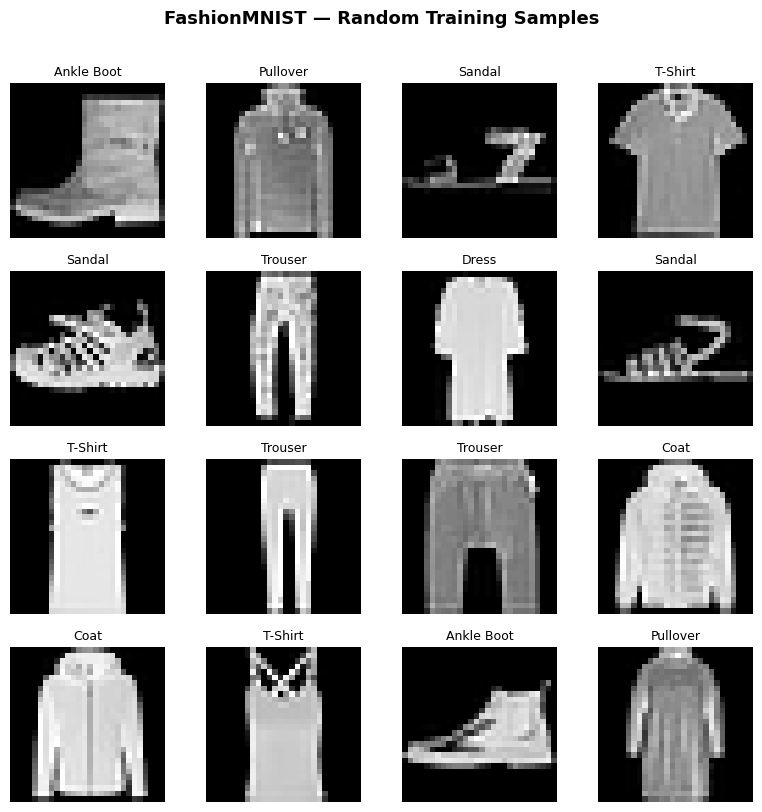

In [3]:
# Download raw dataset (no normalisation) for visualisation only
_raw_train = datasets.FashionMNIST(root="data", train=True,  download=True,
                                    transform=transforms.ToTensor())
_raw_test  = datasets.FashionMNIST(root="data", train=False, download=True,
                                    transform=transforms.ToTensor())

print(f"Train size : {len(_raw_train)}")
print(f"Test size  : {len(_raw_test)}")

# ── Visualise a 4×4 grid ───────────────────────────────────────────────────
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
indices = torch.randperm(len(_raw_train))[:16]
for ax, idx in zip(axes.flat, indices):
    img, label = _raw_train[idx.item()]
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(CLASSES[label], fontsize=9)
    ax.axis("off")
plt.suptitle("FashionMNIST — Random Training Samples", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


---
## 4. DataLoaders <a id='dataloader'></a>

PyTorch's `DataLoader` handles batching, shuffling, and parallel data loading automatically — no manual mini-batch loops needed!

The standard normalisation transform pipeline is:
1. `transforms.ToTensor()` — converts PIL image [0,255] → float tensor [0,1]
2. `transforms.Normalize(mean, std)` — standardises to N(0,1)

**Your Task:** Complete the `build_dataloaders` function by filling in the `# TODO` blocks.


In [4]:
def build_dataloaders(batch_size: int = 128, num_workers: int = 2):
    """
    Download FashionMNIST, apply normalisation transforms,
    and return (train_loader, test_loader).

    Args:
        batch_size  : number of samples per batch
        num_workers : parallel workers for loading (set 0 on Windows)
    Returns:
        train_loader, test_loader
    """
    transform = transforms.Compose([
        # TODO: Add ToTensor() transform
        # Hint: transforms.ToTensor() converts PIL image → float tensor in [0, 1]
        transforms.ToTensor(),
        # TODO: Add Normalize transform using FASHION_MEAN and FASHION_STD
        # Hint: transforms.Normalize(mean_tuple, std_tuple)
        transforms.Normalize(FASHION_MEAN, FASHION_STD),
    ])

    train_dataset = datasets.FashionMNIST(
        root="data", train=True, download=True,
        transform=transform
    )
    test_dataset = datasets.FashionMNIST(
        root="data", train=False, download=True,
        transform=transform
    )

    # Calculate lengths for split (e.g., 60,000 train is being split into 48,000 train and 12,000 val)
    val_size = int(len(train_dataset) * 0.2)
    train_size = len(train_dataset) - val_size
    # Split the dataset
    train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

    train_loader = DataLoader(
        train_subset,
        # TODO: set batch_size, set shuffle to True for training, set num_workers, set pin_memory as True
        batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True
    )
    val_loader = DataLoader(
        val_subset,
        # TODO: set batch_size, set shuffle to False for val, set num_workers, set pin_memory as True
        batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True
    )
    test_loader = DataLoader(
        test_dataset,
        # TODO: set batch_size, set shuffle to False for test, set num_workers, set pin_memory as True
        batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True
    )
    return train_loader, val_loader, test_loader


# Build loaders with default batch size 128
BATCH_SIZE = 128
train_loader, val_loader, test_loader = build_dataloaders(batch_size=BATCH_SIZE)

# ── Sanity-check one batch ──────────────────────────────────────────────────
imgs, labels = next(iter(train_loader))
print(f"Batch image shape : {imgs.shape}")    # Expected: torch.Size([128, 1, 28, 28])
print(f"Batch label shape : {labels.shape}")  # Expected: torch.Size([128])
print(f"Pixel mean (batch): {imgs.mean():.4f}")
print(f"Pixel std  (batch): {imgs.std():.4f}")


Batch image shape : torch.Size([128, 1, 28, 28])
Batch label shape : torch.Size([128])
Pixel mean (batch): -0.0120
Pixel std  (batch): 1.0174


---
## 5. Baseline Linear Model — Rubric A *(15 pts)* <a id='baseline'></a>

### Why start with a linear (fully-connected) model?

Before using convolutional layers, we establish a **baseline** using `nn.Linear` layers — equivalent to the from-scratch network in PA1. This lets us directly measure how much CNNs improve over linear models.

### Architecture Config

We follow the rubric config `[784, 128, 10]` — an input of 784 (flattened 28×28), one hidden layer of 128 units, and 10 output units.

```
Input (784) → Linear(784→128) → Activation → Linear(128→10) → Softmax (via CrossEntropyLoss)
```

### `nn.Sequential` — the easy way

PyTorch's `nn.Sequential` lets you stack layers in order. `nn.CrossEntropyLoss` in PyTorch combines `LogSoftmax + NLLLoss` internally, so **do not add a Softmax layer at the end**.

(NLLLoss is the negative log likelihood loss that you computed in HW-1)

**Your Task:** Complete `build_linear_model` to assemble the `[784, 128, 10]` linear model using `nn.Sequential`.


In [5]:
def build_linear_model(hidden_size: int = 128, activation: str = "relu") -> nn.Module:
    """
    Build a fully-connected (linear) model:
        Flatten → Linear(784, hidden_size) → Activation → Linear(hidden_size, 10)

    Args:
        hidden_size : number of units in the hidden layer (default 128)
        activation  : one of 'relu', 'tanh', 'sigmoid'
    Returns:
        model : nn.Sequential
    """
    # Map activation string to PyTorch module
    ACT_MAP = {
               "relu": nn.ReLU(),              # TODO: call ReLu from nn,
               "tanh": nn.Tanh(),             # TODO: call Tanh from nn,
               "sigmoid": nn.Sigmoid(),             # TODO: call Sigmoid from nn,
               }
    assert activation in ACT_MAP, f"Unknown activation: {activation}"
    act_layer = ACT_MAP[activation]

    model = nn.Sequential(
        # TODO: use nn.Flatten()  — this should help reshape (B, 1, 28, 28) → (B, 784)
        nn.Flatten(),
        # TODO: use nn.Linear(in_features, out_features)
        nn.Linear(784, hidden_size),
        # TODO: act_layer
        act_layer,
        # TODO: use nn.Linear(in_features, out_features)
        # ↑ No Softmax here — CrossEntropyLoss applies it internally
        nn.Linear(hidden_size, NUM_CLASSES),
    )
    return model


# ── Quick architecture check ───────────────────────────────────────────────
linear_model = build_linear_model(hidden_size=128, activation="relu")
linear_model = linear_model.to(device)  # move to GPU/CPU

print(linear_model)
dummy = torch.randn(4, 1, 28, 28).to(device) # here 4 is the batch size, 1 is the no of channels, 28 is the height, 28 is the width
out   = linear_model(dummy)
print(f"Output shape : {out.shape}")   # Expected: torch.Size([4, 10])

# Count parameters
total_params = sum(p.numel() for p in linear_model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")


Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=10, bias=True)
)
Output shape : torch.Size([4, 10])
Total trainable parameters: 101,770


---
## 6. Training & Evaluation Loops <a id='loops'></a>

This section defines the core training infrastructure used by **all** models in this assignment:

| Function | Purpose |
|:---|:---|
| `train_one_epoch` | Run one epoch of mini-batch SGD |
| `evaluate` | Compute loss + accuracy on any loader |
| `train_model` | Full training loop with history tracking & plotting |

### Key PyTorch concepts

- **`optimizer.zero_grad()`** — clears accumulated gradients before each batch
- **`loss.backward()`** — computes all gradients via autograd (backprop is automatic!)
- **`optimizer.step()`** — applies the gradient update to all parameters
- **`model.train()` / `model.eval()`** — switches BatchNorm/Dropout behaviour for training mode and test mode

**Your Task:** Fill in the `# TODO` blocks in `train_one_epoch` and `evaluate`.


In [8]:
def train_one_epoch(model, loader, criterion, optimizer):
    """
    Run one training epoch: forward pass → loss → backward → update.

    Args:
        model     : nn.Module
        loader    : DataLoader (training)
        criterion : loss function (e.g. nn.CrossEntropyLoss())
        optimizer : torch.optim optimizer
    Returns:
        avg_loss : float  — mean loss over all batches
        accuracy : float  — fraction of correct predictions
    """
    # TODO: Set model to training mode
    model.train()

    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        # TODO: Move images and labels to device
        images =  images.to(device)
        labels =  labels.to(device)

        # TODO: Zero out gradients from previous batch
        optimizer.zero_grad()

        # TODO: Forward pass — get model outputs (logits)
        outputs = model(images)

        # TODO: Compute loss using criterion
        loss = criterion(outputs, labels)

        # TODO: Backward pass — compute gradients
        loss.backward()

        # TODO: Update model weights
        optimizer.step()

        # ── Track metrics ─────────────────────────────────────────────────
        total_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total   += labels.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    """
    Evaluate model on a DataLoader (no gradient computation).

    Args:
        model     : nn.Module
        loader    : DataLoader (val or test)
        criterion : loss function
    Returns:
        avg_loss : float
        accuracy : float
    """
    # TODO: Set model to evaluation mode
    model.eval()

    total_loss, correct, total = 0.0, 0, 0

    # TODO: Use torch.no_grad() context manager to disable gradient tracking
    with torch.no_grad():
      for images, labels in loader:
        # TODO: Move data to device
          images = images.to(device)
          labels = labels.to(device)
          # TODO: Forward pass
          outputs = model(images)
          # TODO: Compute loss
          loss = criterion(outputs, labels)

        # ── Track metrics ─────────────────────────────────────────────────
          total_loss += loss.item() * images.size(0)
          _ , predicted = outputs.max(1)
          correct += predicted.eq(labels).sum().item()
          total   += labels.size(0)

    return total_loss / total, correct / total


In [9]:
def train_model(model, train_loader, val_loader, test_loader, num_epochs=50, patience=5,
                lr=1e-3, model_name="Model"):
    """
    Full training loop with per-epoch evaluation and history tracking.

    Args:
        model        : nn.Module (already moved to device)
        train_loader : DataLoader
        test_loader  : DataLoader
        num_epochs   : int
        lr           : learning rate for Adam optimizer
        model_name   : string label for printing
    Returns:
        history : dict with keys 'train_loss', 'train_acc', 'test_loss', 'test_acc'
    """
    # TODO: use the cross entropy loss from nn
    # (Remember that this function already has the Softmax activation applied on the final outputs
    #  and the NLL Loss applied on the predictions - both of which you had to compute manually in PA-1).
    criterion = nn.CrossEntropyLoss()
    # TODO: use the Adam optimizer from torch.optim. Set the model parameters as well as the learning rate
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    # Early Stopping Variables
    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_model_wts = copy.deepcopy(model.state_dict())

    for epoch in range(1, num_epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)    # TODO: Call the train_one_epoch function with the correct data loader
        val_loss, val_acc = evaluate(model, val_loader, criterion)    # TODO: Call the evaluate function with the correct data loader
        elapsed = time.time() - t0

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch:>6} | Train Loss={tr_loss:>10.4f} | Train Acc={tr_acc*100:>8.2f}% | "
              f"Val Loss={val_loss:>9.4f} | Val Acc={val_acc*100:>7.2f}% | Time={elapsed:>5.1f}s")

        # Early Stopping Logic
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict()) # Save best weights
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping triggered at epoch {epoch}")
                break

    # Load best weights before final test evaluation
    model.load_state_dict(best_model_wts)
    test_loss, test_acc =  evaluate(model, test_loader, criterion)    # TODO: Call the evaluate function with the correct data loader
    print(f"\nFinal Test Accuracy (Best Model): {test_acc*100:.2f}%")

    return history


---
## 7. Run Baseline Experiments — Rubric B *(20 pts)* <a id='run_baseline'></a>

We run **three** baseline linear models using different activation functions (`relu`, `tanh`, `sigmoid`) with the fixed architecture `[784, 128, 10]`. This mirrors what you did from scratch in PA1, but now in PyTorch.

### Grading Rubric B

| Sub-task | Points | Requirement |
|:---|:---:|:---|
| B1 | 5 | `relu` model trains and reports final test accuracy |
| B2 | 5 | `tanh` model trains and reports final test accuracy |
| B3 | 5 | `sigmoid` model trains and reports final test accuracy |
| B4 | 5 | Written comparison of the three activations (convergence, accuracy) |

**Your Task:** The training loop is already written. Run the experiments, then fill in the written comparison.


In [10]:
baseline_histories = {}
baseline_models    = {}

for activation in ["relu", "tanh", "sigmoid"]:
    print("Activation used:", activation)
    model_b = build_linear_model(hidden_size=128, activation=activation).to(device)
    hist    = train_model(model_b, train_loader, val_loader, test_loader,
                          num_epochs=15, lr=1e-3,
                          model_name=f"Linear-{activation.upper()}")
    baseline_histories[activation] = hist
    baseline_models[activation]    = model_b


Activation used: relu
Epoch      1 | Train Loss=    0.5123 | Train Acc=   81.86% | Val Loss=   0.4064 | Val Acc=  85.46% | Time= 13.0s
Epoch      2 | Train Loss=    0.3785 | Train Acc=   86.30% | Val Loss=   0.3710 | Val Acc=  86.63% | Time= 11.9s
Epoch      3 | Train Loss=    0.3393 | Train Acc=   87.73% | Val Loss=   0.3569 | Val Acc=  86.74% | Time= 12.7s
Epoch      4 | Train Loss=    0.3145 | Train Acc=   88.54% | Val Loss=   0.3372 | Val Acc=  87.56% | Time= 11.7s
Epoch      5 | Train Loss=    0.2922 | Train Acc=   89.26% | Val Loss=   0.3261 | Val Acc=  87.92% | Time= 10.9s
Epoch      6 | Train Loss=    0.2742 | Train Acc=   89.93% | Val Loss=   0.3160 | Val Acc=  88.46% | Time= 11.6s
Epoch      7 | Train Loss=    0.2664 | Train Acc=   90.22% | Val Loss=   0.3279 | Val Acc=  87.92% | Time= 12.0s
Epoch      8 | Train Loss=    0.2500 | Train Acc=   90.70% | Val Loss=   0.3151 | Val Acc=  88.72% | Time= 11.9s
Epoch      9 | Train Loss=    0.2399 | Train Acc=   91.03% | Val Loss=   0

✏️ **Rubric B4 — Written Comparison (fill in after running):**

**Best activation:** *(e.g., ReLU — achieved 88.42% vs tanh 87.67% vs sigmoid 87.71%)*

**Convergence:** *(Which converged fastest? Explain in terms of gradient flow.)*
ReLU converged fastest, reaching 88%+ validation accuracy by epoch 5. This is because ReLU passes gradients through unchanged for positive values, avoiding the shrinking gradient problem that affects sigmoid and tanh.
**Sigmoid behaviour:** *(Did you observe slower convergence? Relate to the vanishing gradient.)*
Sigmoid started slowest with only 83.75% validation accuracy at epoch 1 compared to ReLU's 85.46%, but caught up by epoch 15. This slower start reflects the vanishing gradient problem — sigmoid squashes outputs between 0 and 1, causing gradients to shrink as they flow back through layers, slowing early learning. Despite this, all three activations converged to similar final accuracies within 15 epochs on this relatively shallow network.
*(Replace with your observations — 4–6 sentences total)*


---
## 8. Build a CNN — Rubric C *(25 pts)* <a id='cnn'></a>

### Why CNNs for images?

Linear models treat each pixel independently — they ignore **spatial structure**. Convolutional layers learn spatially local patterns (edges, textures, shapes) using shared filter weights, dramatically reducing parameters while capturing image structure.

### PyTorch CNN building blocks

| Layer | API | Purpose |
|:---|:---|:---|
| 2D convolution | `nn.Conv2d(in_ch, out_ch, kernel_size, padding)` | Extract local features |
| Batch normalisation | `nn.BatchNorm2d(out_ch)` | Stabilise training |
| ReLU | `nn.ReLU()` | Non-linearity |
| Max pooling | `nn.MaxPool2d(kernel_size, stride)` | Downsample feature maps |
| Dropout | `nn.Dropout(p)` | Regularisation |
| Flatten | `nn.Flatten()` | Reshape for fully-connected |
| Linear | `nn.Linear(in, out)` | Classification head |

### Required CNN Architecture (Rubric C)

Build `FashionCNN` with **at least** the following structure:
Use the table below as a guide to implement the model step by step.

| Stage | Input Shape | Operations | Output Shape |
|------|-------------|------------|--------------|
| Block 1 | (B, 1, 28, 28) | Convolution layer expanding channels from 1 to 32 with a small spatial 3x3 filter that preserves image size (consider a padding of 1) → ReLU activation → Downsampling using 2×2 max pooling | (B, 32, 14, 14) |
| Block 2 | (B, 32, 14, 14) | Convolution layer expanding channels from 32 to 64 while keeping spatial resolution unchanged → ReLU activation → Downsampling using 2×2 max pooling | (B, 64, 7, 7) |
| Block 3 | (B, 64, 7, 7) | Convolution layer expanding channels from 64 to 128 while preserving spatial resolution → ReLU activation | (B, 128, 7, 7) |
| Flatten | (B, 128, 7, 7) | Flatten feature maps into a single vector per example | (B, 6272) |
| Fully Connected Layer 1 | (B, 6272) | Linear projection reducing feature dimension to 256 → ReLU activation | (B, 256) |
| Output Layer | (B, 256) | Linear projection mapping features to class logits (one per FashionMNIST category) | (B, 10) |
---
The final layer outputs **raw logits** (do **not** apply softmax).

You are free to add more layers or increase channels, but must include at least the above.

**Your Task:** Complete the `FashionCNN` class.


In [11]:
class FashionCNN(nn.Module):
    """
    Convolutional neural network for FashionMNIST.

    Architecture (minimum required):
        Block 1: Conv2d(1,  32, 3, pad=1) → BatchNorm → ReLU → MaxPool2d(2,2)
        Block 2: Conv2d(32, 64, 3, pad=1) → BatchNorm → ReLU → MaxPool2d(2,2)
        Block 3: Conv2d(64,128, 3, pad=1) → BatchNorm → ReLU
        Head   : Flatten → Linear(6272,256) → ReLU → Dropout(0.4) → Linear(256,10)
    """

    def __init__(self):
        super(FashionCNN, self).__init__()

        # ── Convolutional Feature Extractor ────────────────────────────────
        self.features = nn.Sequential(
            # Block 1
            # TODO: Conv2d
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            # TODO: ReLU
            nn.ReLU(),
            # TODO: MaxPool2d
            nn.MaxPool2d(2, 2),

            # Block 2
            # TODO: Conv2d
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            # TODO: ReLU
            nn.ReLU(),
            # TODO: MaxPool2d
            nn.MaxPool2d(2, 2),

            # Block 3
            # TODO: Conv2d
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            # TODO: ReLU
            nn.ReLU(),
            # NOTE: No MaxPool here — we keep 7×7 spatial resolution
        )

        # ── Classification Head ────────────────────────────────────────────
        self.classifier = nn.Sequential(
            # TODO: Flatten into a single vector
            nn.Flatten(),
            # TODO: Fully Connected Linear Layer
            nn.Linear(6272, 256),
            # TODO: ReLU
            nn.ReLU(),
            nn.Dropout(0.4),
            # TODO: Linear layer to the number of classes in the dataset
            nn.Linear(256, NUM_CLASSES),
        )

    def forward(self, x):
        # TODO: Pass x through the feature extractor, then through the classification head
        x = self.features(x)
        x = self.classifier(x)
        return x


# ── Architecture check ─────────────────────────────────────────────────────
cnn_model = FashionCNN().to(device)
print(cnn_model)

dummy = torch.randn(4, 1, 28, 28).to(device)
out   = cnn_model(dummy)
print(f"Output shape : {out.shape}")   # Expected: torch.Size([4, 10])

total_cnn = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
total_lin = sum(p.numel() for p in linear_model.parameters() if p.requires_grad)
print(f"CNN parameters    : {total_cnn:,}")
print(f"Linear parameters : {total_lin:,}")
print(f"CNN / Linear ratio: {total_cnn / total_lin:.1f}x")


FashionCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=6272, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=256, out_features=10, bias=True)

---
## 9. Train & Compare CNN vs Baseline — Rubric D *(20 pts)* <a id='compare'></a>

### Grading Rubric D

| Sub-task | Points | Requirement |
|:---|:---:|:---|
| D1 | 10 | Train CNN for ≥ 15 epochs; report final test accuracy |
| D2 | 5  | Compare CNN vs best linear model numerically |
| D3 | 5  | Written explanation of why CNN outperforms linear |

**Your Task:** Train the CNN, then fill in the written analysis.


In [12]:
# ── Train CNN ──────────────────────────────────────────────────────────────
cnn_model   = FashionCNN().to(device)
cnn_history = train_model(cnn_model, train_loader, val_loader, test_loader,
                           num_epochs=15, lr=1e-3, model_name="FashionCNN")

Epoch      1 | Train Loss=    0.4216 | Train Acc=   84.90% | Val Loss=   0.2816 | Val Acc=  89.59% | Time= 13.1s
Epoch      2 | Train Loss=    0.2788 | Train Acc=   89.74% | Val Loss=   0.2430 | Val Acc=  91.26% | Time= 12.6s
Epoch      3 | Train Loss=    0.2343 | Train Acc=   91.29% | Val Loss=   0.2337 | Val Acc=  91.23% | Time= 13.0s
Epoch      4 | Train Loss=    0.2122 | Train Acc=   92.19% | Val Loss=   0.2380 | Val Acc=  91.04% | Time= 12.6s
Epoch      5 | Train Loss=    0.1813 | Train Acc=   93.14% | Val Loss=   0.2232 | Val Acc=  92.19% | Time= 12.6s
Epoch      6 | Train Loss=    0.1654 | Train Acc=   93.89% | Val Loss=   0.2345 | Val Acc=  91.61% | Time= 12.6s
Epoch      7 | Train Loss=    0.1451 | Train Acc=   94.53% | Val Loss=   0.2222 | Val Acc=  92.33% | Time= 12.5s
Epoch      8 | Train Loss=    0.1234 | Train Acc=   95.39% | Val Loss=   0.2308 | Val Acc=  92.58% | Time= 12.5s
Epoch      9 | Train Loss=    0.1145 | Train Acc=   95.68% | Val Loss=   0.2345 | Val Acc=  92.4

✏️ **Rubric D3 — Written Analysis (fill in after running):**

**CNN test accuracy:** *(e.g., 91.65%)*
**Best linear accuracy:** *(e.g., 88.42%)*

**Why does CNN outperform linear?**
*(Explain in terms of: local receptive fields, weight sharing, spatial hierarchy, parameter efficiency — 4–6 sentences)*
The CNN outperforms the linear model because it is specifically designed for images. Instead of treating every pixel independently like the linear model does, the CNN looks at small local patches of pixels at a time, which makes more sense since nearby pixels in an image are related to each other. The same filters are reused across the entire image so the network can recognize a feature like an edge or a curve no matter where it appears. Each layer builds on the previous one, learning simple patterns first and combining them into more complex shapes deeper in the network. This makes the CNN much better at understanding the visual structure of clothing items compared to a flat fully connected model.


---
## 10. Plots & Analysis — Rubric E *(10 pts)* <a id='plots'></a>

Visualise the training dynamics of all models. Good plots show learning curves (loss and accuracy vs epoch), help diagnose overfitting, and allow fair comparison.

**Your Task:** The plotting function is provided. Run it for all models.


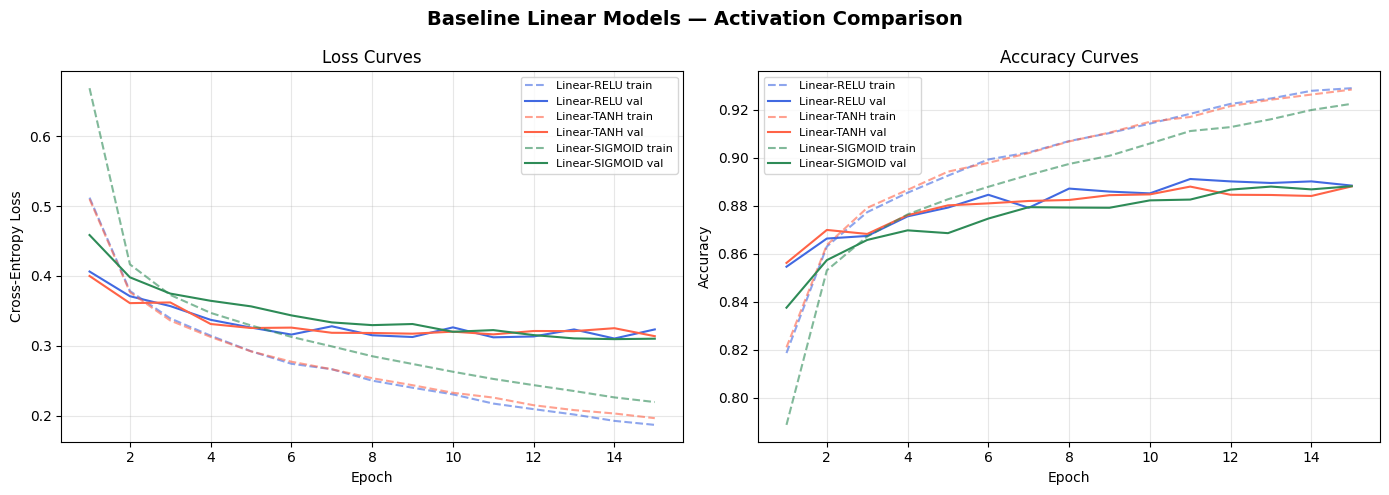

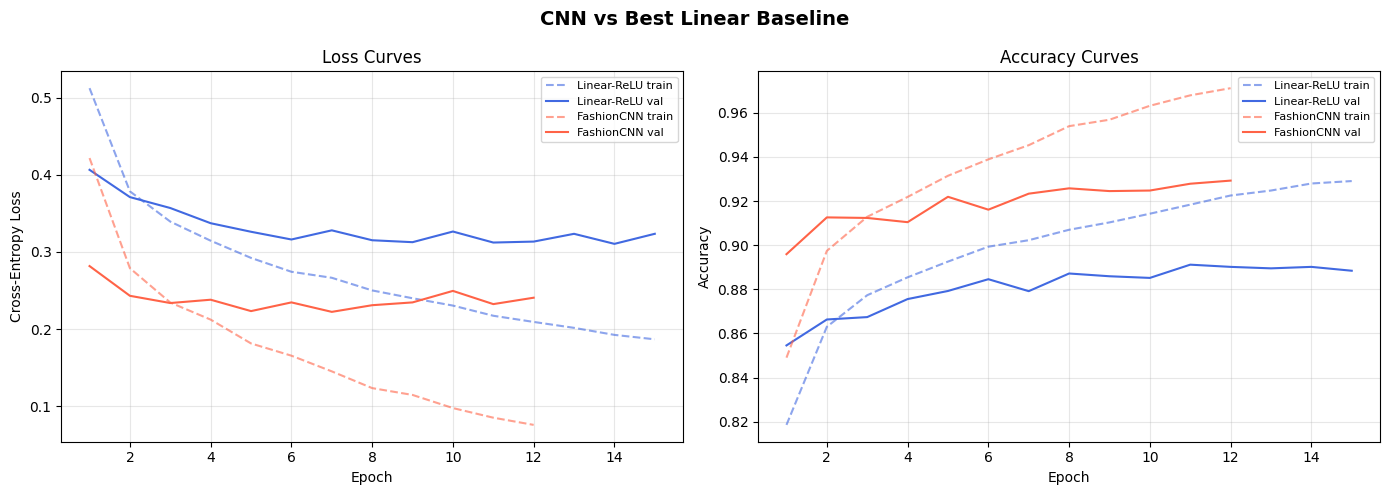

In [13]:
def plot_history(history_dict: dict, title: str = "Training Curves"):
    """
    Plot loss and accuracy curves for one or more models.

    Args:
        history_dict : {model_name: history_dict}  (history from train_model)
        title        : figure title
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colours = ["royalblue", "tomato", "seagreen", "darkorange", "purple"]

    for (name, hist), colour in zip(history_dict.items(), colours):
        epochs = range(1, len(hist["train_loss"]) + 1)
        axes[0].plot(epochs, hist["train_loss"], "--",  color=colour, alpha=0.6, label=f"{name} train")
        axes[0].plot(epochs, hist["val_loss"],  "-",   color=colour,             label=f"{name} val")
        axes[1].plot(epochs, hist["train_acc"],  "--",  color=colour, alpha=0.6, label=f"{name} train")
        axes[1].plot(epochs, hist["val_acc"],   "-",   color=colour,             label=f"{name} val")

    for ax, ylabel, ylbl in zip(axes, ["Cross-Entropy Loss", "Accuracy"],
                                 ["Loss", "Accuracy"]):
        ax.set_xlabel("Epoch")
        ax.set_ylabel(ylabel)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    axes[0].set_title("Loss Curves")
    axes[1].set_title("Accuracy Curves")
    plt.suptitle(title, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()


# ── Plot 1: All linear baselines ───────────────────────────────────────────
plot_history(
    {f"Linear-{k.upper()}": v for k, v in baseline_histories.items()},
    title="Baseline Linear Models — Activation Comparison"
)

# ── Plot 2: CNN vs best linear (relu) ──────────────────────────────────────
plot_history(
    {"Linear-ReLU": baseline_histories["relu"],
     "FashionCNN":  cnn_history},
    title="CNN vs Best Linear Baseline"
)


✏️ **Rubric E — Plot Analysis (fill in after running):**

**Observation 1 (loss curves):** *(Does the CNN show lower loss? Is there a gap between train and validation loss suggesting overfitting?)*
The CNN shows lower loss than the linear model throughout training. There is a noticeable gap between the CNN's train and validation loss by the end, suggesting mild overfitting, but the validation loss is still much lower than the linear model's.

**Observation 2 (accuracy curves):** *(Does the CNN plateau later, or reach a higher final accuracy?)*
The CNN reaches a higher final accuracy of 91.65% compared to the linear model's 88.42%. The CNN also continues improving longer before plateauing, while the linear model flattens out earlier around epoch 4-5.

**Observation 3 (convergence):** *(Which model converged fastest in terms of epochs?)*
The linear model converged faster in terms of epochs, reaching close to its final accuracy within the first few epochs. The CNN took more epochs to reach its peak but ultimately achieved a higher accuracy.

---
## 11. Save the Model <a id='save'></a>

PyTorch best practice: save only the **state dictionary** (weights), not the full model object. This is portable across Python versions and class definitions.


In [14]:
os.makedirs("saved_models", exist_ok=True)

# Save CNN
torch.save(cnn_model.state_dict(), "saved_models/fashion_cnn.pth")
print("CNN model saved → saved_models/fashion_cnn.pth")

# ── Reload and verify ──────────────────────────────────────────────────────
cnn_reload = FashionCNN().to(device)
cnn_reload.load_state_dict(torch.load("saved_models/fashion_cnn.pth", map_location=device))
cnn_reload.eval()

criterion = nn.CrossEntropyLoss()
reload_loss, reload_acc = evaluate(cnn_reload, test_loader, criterion)
print(f"Reloaded model test accuracy: {reload_acc*100:.2f}%")
print("This reloaded model test accuracy should be the same as the model test accuracy you obtained while testing the FashionCNN")

CNN model saved → saved_models/fashion_cnn.pth
Reloaded model test accuracy: 91.65%
This reloaded model test accuracy should be the same as the model test accuracy you obtained while testing the FashionCNN


---
## 12. Team Contributions <a id='team'></a>

> Each team member **must** write a paragraph (3–5 sentences) describing their contribution. Grades may differ for team members with unequal contributions. **Everyone should have written code.**

**Team Member 1 — [Patrick Elles]:**
Whole thing

---

**Team Member 2 — [Name]:**
*(Replace with your contribution)*


---
## 13. AI Use Log <a id='ailog'></a>

If you used ChatGPT, Copilot, or any other AI tool, document every instance below. If none, write **"No AI tools used."**

| # | Tool | Prompt / Task | What it generated | What you changed |
|:---:|:---:|:---|:---|:---|
| — | — | No AI tools used. | — | — |
